# 05 — Business Evaluation
**Credit Risk Scoring Pipeline | Project 1**

A high ROC-AUC is necessary but not enough for credit risk.  
Lenders need to answer practical questions:

- At what score threshold should we reject an application?
- How many good customers do we lose when we reject bad ones?
- What is the expected profit or loss at each threshold?

This notebook translates model performance into business metrics:  
KS statistic, score bands (decile analysis), approval rate analysis, and a profit curve.


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', font_scale=1.1)

print('Libraries loaded.')


Libraries loaded.


## Step 1 — Load Model and Predictions

In [2]:
with open('../outputs/best_model_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

sel  = bundle['selector']
ct   = bundle['preprocessor']
model = bundle['model']

df = pd.read_csv('../data/processed/features_engineered.csv')
X  = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y  = df['TARGET']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_test_proc = ct.transform(sel.transform(X_test))
y_proba     = model.predict_proba(X_test_proc)[:, 1]

eval_df = pd.DataFrame({'y_true': y_test.values, 'proba': y_proba})
print(f'Test set: {len(eval_df):,} applicants  |  default rate: {y_test.mean()*100:.1f}%')
print(f'Model test ROC-AUC: {bundle["test_roc_auc"]}')


Test set: 61,503 applicants  |  default rate: 8.1%
Model test ROC-AUC: 0.754


## Step 2 — KS Statistic

The Kolmogorov-Smirnov (KS) statistic is the industry standard for credit scorecards.  
It measures the maximum separation between the cumulative distribution of good and bad applicants.  
A KS above 40 is generally considered acceptable for a production scorecard.


KS Statistic : 0.3795  (37.9)
KS Threshold : 0.4935
Interpretation: Acceptable (30-40)


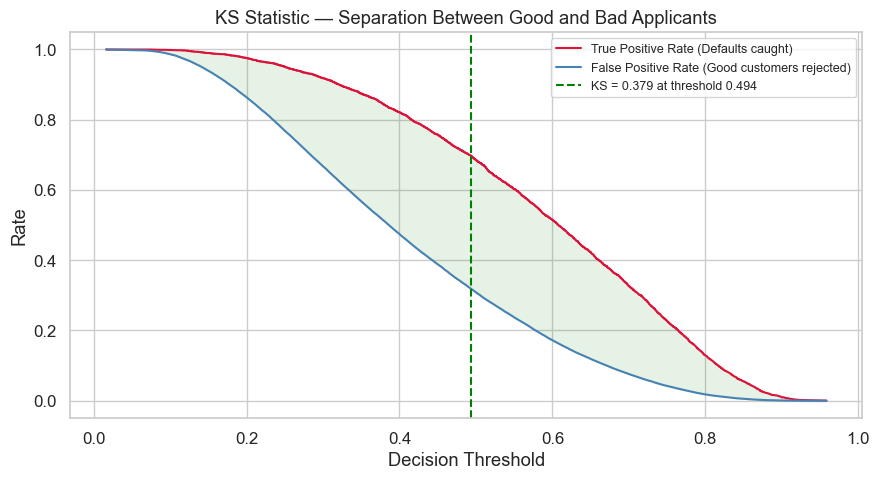

Saved: outputs/figures/05_ks_statistic.png


In [3]:
fpr, tpr, thresholds = roc_curve(eval_df['y_true'], eval_df['proba'])
ks_values = tpr - fpr
ks_stat   = ks_values.max()
ks_thresh = thresholds[ks_values.argmax()]

print(f'KS Statistic : {ks_stat:.4f}  ({ks_stat*100:.1f})')
print(f'KS Threshold : {ks_thresh:.4f}')
print(f'Interpretation: {"Good (>=40)" if ks_stat >= 0.40 else "Acceptable (30-40)" if ks_stat >= 0.30 else "Weak (<30)"}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds[::-1], tpr[::-1],  label='True Positive Rate (Defaults caught)', color='crimson')
ax.plot(thresholds[::-1], fpr[::-1],  label='False Positive Rate (Good customers rejected)', color='steelblue')
ax.axvline(ks_thresh, color='green', linestyle='--', linewidth=1.5,
           label=f'KS = {ks_stat:.3f} at threshold {ks_thresh:.3f}')
ax.fill_between(thresholds[::-1], tpr[::-1], fpr[::-1], alpha=0.1, color='green')
ax.set(xlabel='Decision Threshold', ylabel='Rate', title='KS Statistic — Separation Between Good and Bad Applicants')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_ks_statistic.png', dpi=150)
plt.show()
print('Saved: outputs/figures/05_ks_statistic.png')


## Step 3 — Decile Analysis (Score Bands)

We divide applicants into 10 equal groups (deciles) by predicted risk score.  
Decile 1 = highest risk, Decile 10 = lowest risk.

A good model should show a clear, monotonic drop in default rate from decile 1 to 10.  
This table is what a credit risk team would review before deploying a scorecard.


In [4]:
eval_df['decile'] = pd.qcut(eval_df['proba'], q=10, labels=False, duplicates='drop')
eval_df['decile'] = eval_df['decile'].max() - eval_df['decile']  # flip: 0 = highest risk

decile_table = eval_df.groupby('decile').agg(
    applicants    = ('y_true', 'count'),
    defaults      = ('y_true', 'sum'),
    avg_score     = ('proba', 'mean'),
).reset_index()

decile_table['default_rate']    = decile_table['defaults'] / decile_table['applicants']
decile_table['cum_defaults']    = decile_table['defaults'].cumsum()
decile_table['cum_applicants']  = decile_table['applicants'].cumsum()
decile_table['cum_default_rate']= decile_table['cum_defaults'] / decile_table['defaults'].sum()
decile_table['cum_approval_rate']= 1 - (decile_table['cum_applicants'] / decile_table['applicants'].sum())

decile_table.index = range(1, len(decile_table)+1)
decile_table.index.name = 'Decile'
print(decile_table[['applicants','defaults','avg_score','default_rate','cum_default_rate']].to_string())


        applicants  defaults  avg_score  default_rate  cum_default_rate
Decile                                                                 
1             6151      1668   0.769660      0.271175          0.335952
2             6150       892   0.645029      0.145041          0.515609
3             6150       613   0.562586      0.099675          0.639074
4             6150       506   0.492958      0.082276          0.740987
5             6150       393   0.430618      0.063902          0.820141
6             6151       298   0.373454      0.048447          0.880161
7             6150       214   0.319661      0.034797          0.923263
8             6150       165   0.267507      0.026829          0.956495
9             6150       129   0.213155      0.020976          0.982477
10            6151        87   0.139262      0.014144          1.000000


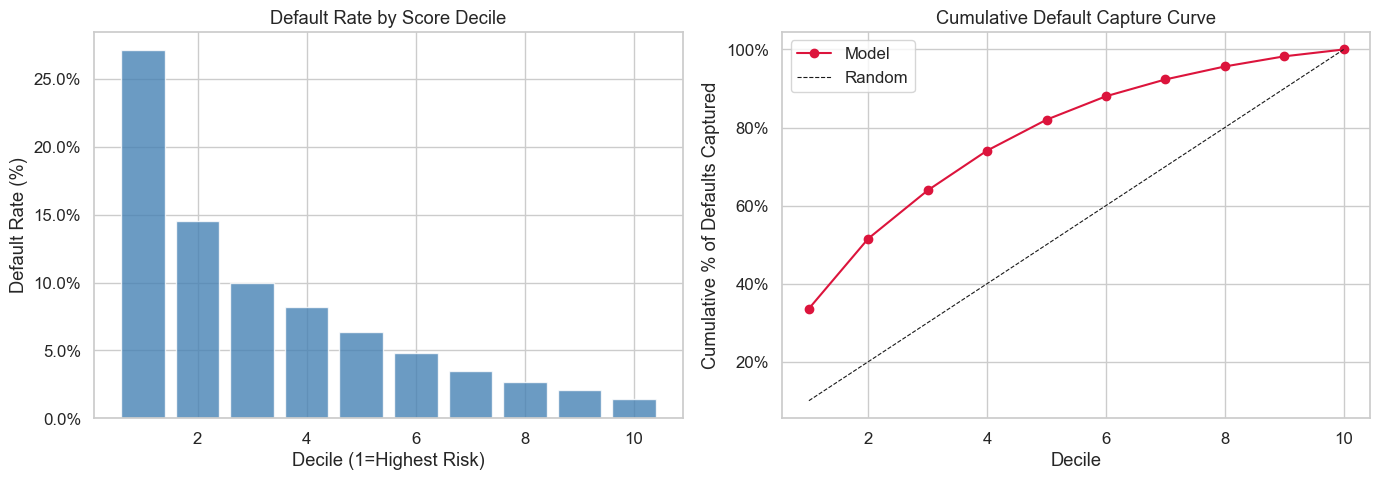

Saved: outputs/figures/05_decile_analysis.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by decile
axes[0].bar(decile_table.index, decile_table['default_rate'] * 100, color='steelblue', alpha=0.8)
axes[0].set(xlabel='Decile (1=Highest Risk)', ylabel='Default Rate (%)',
            title='Default Rate by Score Decile')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Cumulative default capture curve
axes[1].plot(decile_table.index, decile_table['cum_default_rate'] * 100,
             marker='o', color='crimson', label='Model')
axes[1].plot([1, 10], [10, 100], 'k--', linewidth=0.8, label='Random')
axes[1].set(xlabel='Decile', ylabel='Cumulative % of Defaults Captured',
            title='Cumulative Default Capture Curve')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_decile_analysis.png', dpi=150)
plt.show()
print('Saved: outputs/figures/05_decile_analysis.png')


## Step 4 — Approval Rate vs Default Rate Tradeoff

This chart answers the key business question:  
**"If we reject the top X% of risky applicants, how many defaults do we avoid — and how many good customers do we also reject?"**

The right threshold depends on the lender's risk appetite.


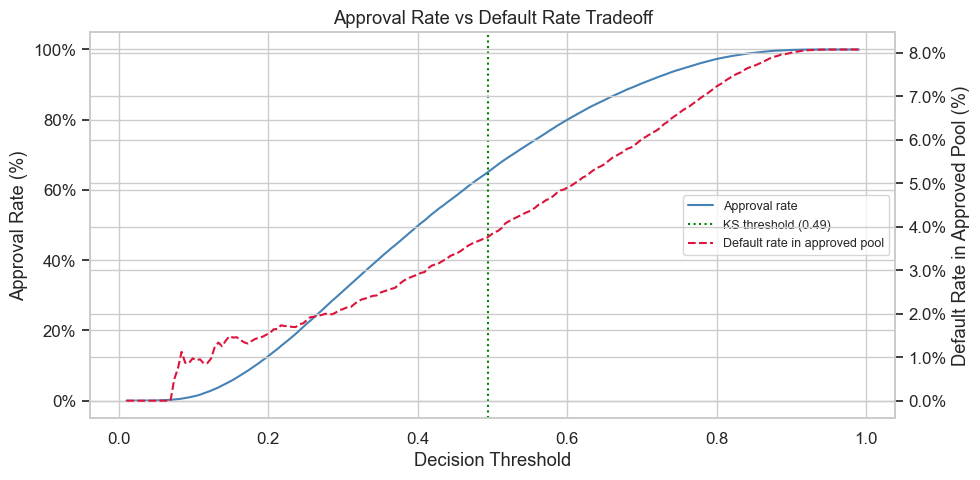

Saved: outputs/figures/05_approval_default_tradeoff.png


In [6]:
thresholds_range = np.linspace(0.01, 0.99, 200)
approval_rates, default_rates_approved = [], []

for t in thresholds_range:
    approved     = eval_df[eval_df['proba'] < t]
    approval_rate = len(approved) / len(eval_df)
    default_rate_in_approved = approved['y_true'].mean() if len(approved) > 0 else 0
    approval_rates.append(approval_rate * 100)
    default_rates_approved.append(default_rate_in_approved * 100)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds_range, approval_rates, color='steelblue', label='Approval rate')
ax2.plot(thresholds_range, default_rates_approved, color='crimson', linestyle='--', label='Default rate in approved pool')

ax1.axvline(ks_thresh, color='green', linestyle=':', linewidth=1.5, label=f'KS threshold ({ks_thresh:.2f})')

ax1.set(xlabel='Decision Threshold', ylabel='Approval Rate (%)')
ax2.set_ylabel('Default Rate in Approved Pool (%)')
ax1.set_title('Approval Rate vs Default Rate Tradeoff')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_approval_default_tradeoff.png', dpi=150)
plt.show()
print('Saved: outputs/figures/05_approval_default_tradeoff.png')


## Step 5 — Expected Profit Curve

We assign a business value to each outcome:
- **True Negative** (correctly approved good customer): +£500 expected profit from the loan
- **True Positive** (correctly rejected bad customer): £0 (no loan given, no loss)
- **False Positive** (good customer wrongly rejected): −£500 (lost profit opportunity)
- **False Negative** (bad customer approved): −£2,000 (expected loss on default)

These are illustrative figures. A real lender would use their actual LGD (Loss Given Default).


Profit at default threshold (0.50) : £7,522,000
Profit at optimal threshold (0.81)  : £18,627,000
Improvement from threshold tuning   : £11,105,000


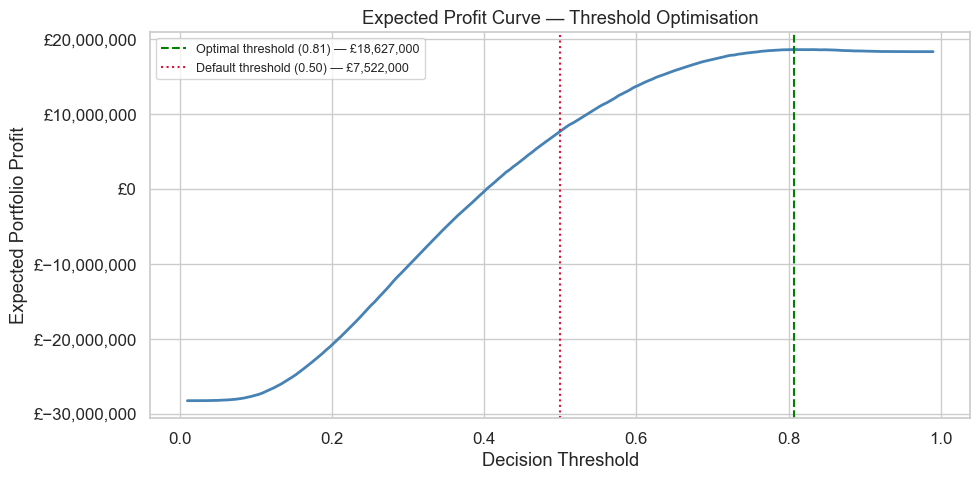

Saved: outputs/figures/05_profit_curve.png


In [7]:
PROFIT_TN = 500    # profit from a good loan correctly approved
PROFIT_TP = 0      # no loan given to a bad applicant — avoided loss but no profit
COST_FP   = -500   # good customer rejected — lost profit opportunity
COST_FN   = -2000  # bad customer approved — expected default loss

profit_by_threshold = []

for t in thresholds_range:
    y_pred = (eval_df['proba'] >= t).astype(int)
    tn = ((y_pred == 0) & (eval_df['y_true'] == 0)).sum()
    tp = ((y_pred == 1) & (eval_df['y_true'] == 1)).sum()
    fp = ((y_pred == 1) & (eval_df['y_true'] == 0)).sum()
    fn = ((y_pred == 0) & (eval_df['y_true'] == 1)).sum()
    total_profit = tn * PROFIT_TN + tp * PROFIT_TP + fp * COST_FP + fn * COST_FN
    profit_by_threshold.append(total_profit)

profit_array     = np.array(profit_by_threshold)
best_thresh_idx  = profit_array.argmax()
best_thresh      = thresholds_range[best_thresh_idx]
best_profit      = profit_array[best_thresh_idx]

# Profit at default threshold (0.5) for comparison
default_thresh_idx = np.abs(thresholds_range - 0.5).argmin()
default_profit     = profit_array[default_thresh_idx]

print(f'Profit at default threshold (0.50) : £{default_profit:,.0f}')
print(f'Profit at optimal threshold ({best_thresh:.2f})  : £{best_profit:,.0f}')
print(f'Improvement from threshold tuning   : £{best_profit - default_profit:,.0f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, profit_array, color='steelblue', linewidth=2)
ax.axvline(best_thresh, color='green', linestyle='--', linewidth=1.5,
           label=f'Optimal threshold ({best_thresh:.2f}) — £{best_profit:,.0f}')
ax.axvline(0.5, color='crimson', linestyle=':', linewidth=1.5,
           label=f'Default threshold (0.50) — £{default_profit:,.0f}')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
ax.set(xlabel='Decision Threshold', ylabel='Expected Portfolio Profit',
       title='Expected Profit Curve — Threshold Optimisation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_profit_curve.png', dpi=150)
plt.show()
print('Saved: outputs/figures/05_profit_curve.png')


## Step 6 — Final Business Summary

In [8]:
print('=' * 55)
print('CREDIT RISK MODEL — BUSINESS EVALUATION SUMMARY')
print('=' * 55)
print(f'  Test set size         : {len(eval_df):,} applicants')
print(f'  Population default rate: {eval_df["y_true"].mean()*100:.1f}%')
print()
print(f'  ROC-AUC               : {bundle["test_roc_auc"]}')
print(f'  KS Statistic          : {ks_stat*100:.1f}  (>=40 = good)')
print()
print(f'  Optimal threshold     : {best_thresh:.2f}')
print(f'  Expected profit (opt) : £{best_profit:,.0f}')
print(f'  Expected profit (0.5) : £{default_profit:,.0f}')
print(f'  Profit lift           : £{best_profit - default_profit:,.0f}')
print()
print(f'  Top decile default rate : {decile_table["default_rate"].iloc[0]*100:.1f}%')
print(f'  Bottom decile def. rate : {decile_table["default_rate"].iloc[-1]*100:.1f}%')
print(f'  Separation ratio        : {decile_table["default_rate"].iloc[0] / decile_table["default_rate"].iloc[-1]:.1f}x')
print('=' * 55)


CREDIT RISK MODEL — BUSINESS EVALUATION SUMMARY
  Test set size         : 61,503 applicants
  Population default rate: 8.1%

  ROC-AUC               : 0.754
  KS Statistic          : 37.9  (>=40 = good)

  Optimal threshold     : 0.81
  Expected profit (opt) : £18,627,000
  Expected profit (0.5) : £7,522,000
  Profit lift           : £11,105,000

  Top decile default rate : 27.1%
  Bottom decile def. rate : 1.4%
  Separation ratio        : 19.2x
